# Phase 03 — Exploratory Data Analysis

*Agriculture Risk Monitoring System — Master research-grade portfolio (Project 5).*

**Goal (scope §6.2):** establish a baseline empirical understanding of climate and yield variation across the AAGIS broadacre regions — *where, when, and how much* — and record the optional-crop decision (sorghum / cotton).

**How to run:** execute top-to-bottom on a fresh kernel. The kernel must be the project `.venv` (Python 3.12); do **not** use a base conda kernel. Every figure carries a one-sentence interpretation beneath it (scope §11.9).

**Build order (steps):** s01 setup + verified data inventory → s02 regional climate climatology (this commit) → s03 yield trends & dispersion → s04 climate–yield joint view + historical-event sanity → s05 optional-crop decision → s06 closure.


## 0. Setup & verified data inventory

In [1]:
# Bootstrap: put the repo root on sys.path so `from src...` works from notebooks/.
import sys
from pathlib import Path

_REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import pandas as pd

from src.viz.style import apply_style, SEED
from src.processing.input_inventory import (
    build_inventory,
    check_invariants,
    reliable_yield_summary,
)

apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
print(f"repo root: {_REPO_ROOT}")
print(f"SEED = {SEED}")


repo root: C:\Users\kotae\Documents\Portfolio\project\Project 5\agriculture-risk-monitoring-system
SEED = 42


### 0.1 Product inventory
The Phase 02 analysis-ready inputs and their shapes (same inventory the `phase03_s01_data_inventory.py` orchestrator writes to `outputs/tables/s01_input_inventory.csv`).

In [2]:
inventory = build_inventory()
inventory[["product", "path", "exists", "n_rows", "expected_rows", "row_ok"]]


,product,path,exists,n_rows,expected_rows,row_ok
0,region_mapping,region_mapping.csv,True,32,32.0,True
1,wheat,abares/wheat.csv,True,1114,1114.0,True
2,barley,abares/barley.csv,True,1114,1114.0,True
3,canola,abares/canola.csv,True,1114,1114.0,True
4,wheat_totals,abares/wheat_region_totals.csv,True,1114,1114.0,True
5,barley_totals,abares/barley_region_totals.csv,True,1114,1114.0,True
6,canola_totals,abares/canola_region_totals.csv,True,1114,1114.0,True
7,silo_annual,silo_region_means/annual_1991_2020.csv,True,5400,5400.0,True
8,silo_monthly,silo_region_means/monthly_climatology_1991_202...,True,2160,2160.0,True
9,silo_cell_map,silo_cell_region_map.parquet,True,28577,28577.0,True


### 0.2 Structural invariants
Region-key alignment across the yield (region name) and climate (aagis_code) products, and full coverage of the 20 broadacre regions. Fails loudly if a Phase 02 output drifted.

In [3]:
checks = check_invariants()
failed = [c.name for c in checks if not c.ok]
for c in checks:
    print(f"[{'OK ' if c.ok else 'FAIL'}] {c.name}: {c.detail}")
assert not failed, f"structural invariants failed: {failed}"


[OK ] region_mapping_32: 32 rows, 32 unique codes
[OK ] broadacre_count_20: 20 broadacre regions (want 20)
[OK ] silo_annual_structure: 30 regions x 6 vars x 30 years
[OK ] silo_covers_broadacre: all 20 broadacre regions present
[OK ] silo_uncovered_are_pastoral: uncovered=['511', '711'] zones=['Pastoral'] (want 511,711 both Pastoral)
[OK ] silo_region_names_in_mapping: region_name subset of mapping
[OK ] silo_monthly_structure: 30 regions x 6 vars x 12 months
[OK ] wheat_regions_in_mapping: region names subset of mapping
[OK ] wheat_covers_broadacre: all 20 broadacre regions present
[OK ] barley_regions_in_mapping: region names subset of mapping
[OK ] barley_covers_broadacre: all 20 broadacre regions present
[OK ] canola_regions_in_mapping: region names subset of mapping
[OK ] canola_covers_broadacre: all 20 broadacre regions present


### 0.3 Reliable yield windows
Per-commodity yield coverage and rows before each crop's reliable window (wheat/barley 1990+, canola 1994+ per the RSE gate, scope v5.1 §3.3).

In [4]:
reliable = reliable_yield_summary()
reliable


,commodity,reliable_start,rows,non_na_yield,min_year,max_year,pre_window_rows,pre_window_non_na_yield
0,wheat,1990,1114,747,1990,2024,0,0
1,barley,1990,1114,738,1990,2024,0,0
2,canola,1994,1114,482,1990,2024,122,28


**Interpretation (s01).** The Phase 02 inputs load cleanly and all structural invariants hold: 32 mapped regions, 20 broadacre regions jointly present in the yield and climate products, and the two SILO-uncovered regions are exactly the pastoral 511 / 711. Canola carries 122 pre-1994 rows (28 with a non-NA yield) that the reliable window excludes. The data baseline is verified; substantive EDA follows.

## 1. Regional climate climatology (SILO, 1961–2024)

Where, when, and how much climate varies across the 20 broadacre regions, from the full-record SILO region means (`annual_1961_2024.csv`, s02) and the 1991–2020 monthly climatology. Pastoral regions are shown in grey for context but excluded from the cropping analysis.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from src.viz import maps
from src.viz.style import (
    OKABE_ITO,
    CMAP_RAINFALL,
    CMAP_TEMPERATURE,
    CMAP_ANOMALY,
    savefig,
)
from src.processing.silo_climatology import load_annual_full_record, load_baselines

ann = load_annual_full_record()
bl = load_baselines()
mon = pd.read_csv(
    _REPO_ROOT / "data/processed/silo_region_means/monthly_climatology_1991_2020.csv",
    dtype={"aagis_code": str},
)
mapping = pd.read_csv(
    _REPO_ROOT / "data/processed/region_mapping.csv", dtype={"aagis_code": str}
)
broad = mapping[mapping.zone.isin(["Wheat Sheep", "High Rainfall"])].sort_values(
    "region_name"
)
broad_codes = set(broad.aagis_code)

# baselines in wide form for the spatial and shift maps
blw = bl.pivot_table(
    index=["aagis_code", "variable"], columns="baseline", values="value"
).reset_index()
print(f"annual rows: {len(ann):,} | baseline rows: {len(bl):,}")


annual rows: 11,250 | baseline rows: 360

### 1.1 Spatial baseline — where it is wet and hot (1991–2020)

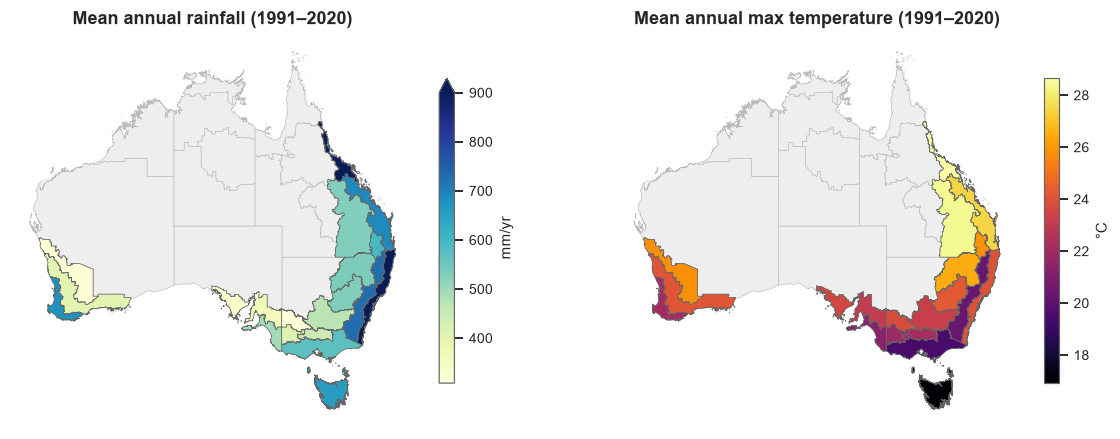

In [6]:
rain_b = blw[blw.variable == "daily_rain"][["aagis_code", "1991-2020"]].rename(
    columns={"1991-2020": "rain_mm"}
)
tmax_b = blw[blw.variable == "max_temp"][["aagis_code", "1991-2020"]].rename(
    columns={"1991-2020": "tmax_c"}
)
fig, axs = plt.subplots(1, 2, figsize=(13, 6))
maps.region_choropleth(
    rain_b, "rain_mm", ax=axs[0], cmap=CMAP_RAINFALL, label="mm/yr",
    title="Mean annual rainfall (1991–2020)", vmax_cap=900,
)
maps.region_choropleth(
    tmax_b, "tmax_c", ax=axs[1], cmap=CMAP_TEMPERATURE, label="°C",
    title="Mean annual max temperature (1991–2020)",
)
savefig(fig, "s02_spatial_climatology_baseline")
plt.show()


**Interpretation.** Rainfall rises from the dry western/interior wheat-belt (WA and eastern SA/VIC Mallee, ~300–400 mm/yr) toward the wetter eastern and coastal margins (the colour bar is capped at 900 mm/yr so the cropping gradient stays legible; tropical QLD coast exceeds it). Max temperature falls monotonically with latitude — hot in the QLD/WA north, coolest in Tasmania — so the broadacre belt spans a wide hot-dry ↔ cool-wet climate space.

### 1.2 Seasonality — when the rain falls

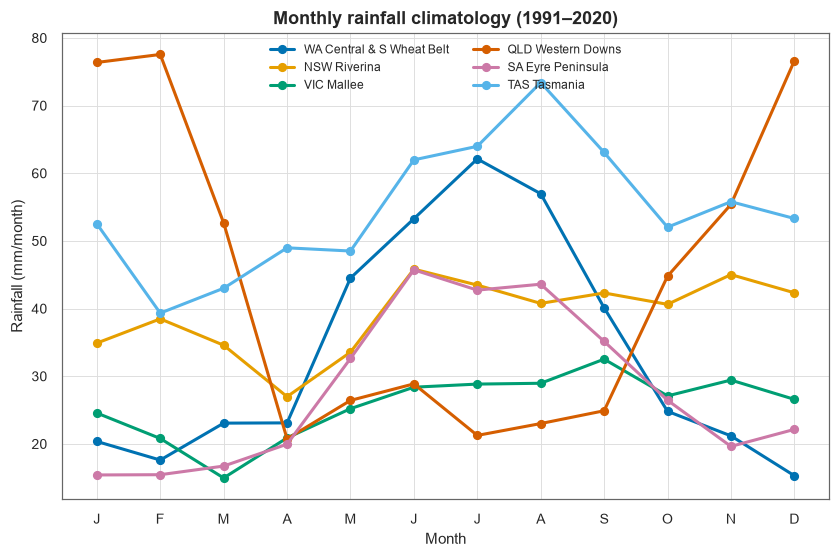

In [7]:
reps = {
    "521": "WA Central & S Wheat Belt",
    "123": "NSW Riverina",
    "221": "VIC Mallee",
    "322": "QLD Western Downs",
    "421": "SA Eyre Peninsula",
    "631": "TAS Tasmania",
}
mr = mon[mon.variable == "daily_rain"]
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (c, lab) in enumerate(reps.items()):
    s = mr[mr.aagis_code == c].sort_values("month")
    ax.plot(s.month, s.value, marker="o", ms=5, lw=2, color=OKABE_ITO[i], label=lab)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(list("JFMAMJJASOND"))
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall (mm/month)")
ax.set_title("Monthly rainfall climatology (1991–2020)")
ax.legend(ncol=2, fontsize=8)
savefig(fig, "s02_rainfall_seasonality")
plt.show()


**Interpretation.** The southern and western regions (WA Wheat Belt, SA Eyre, VIC Mallee) are **winter-dominant** (Mediterranean; rain peaks May–August, aligning with the winter-crop growing season), while QLD Western Downs is **summer-dominant** (monsoonal; December–February peak). This growing-season timing split is central to how climate stress will map onto wheat/barley/canola vs summer crops (relevant to the optional-crop decision in s05).

### 1.3 Interannual variation & trend — annual rainfall, 1961–2024

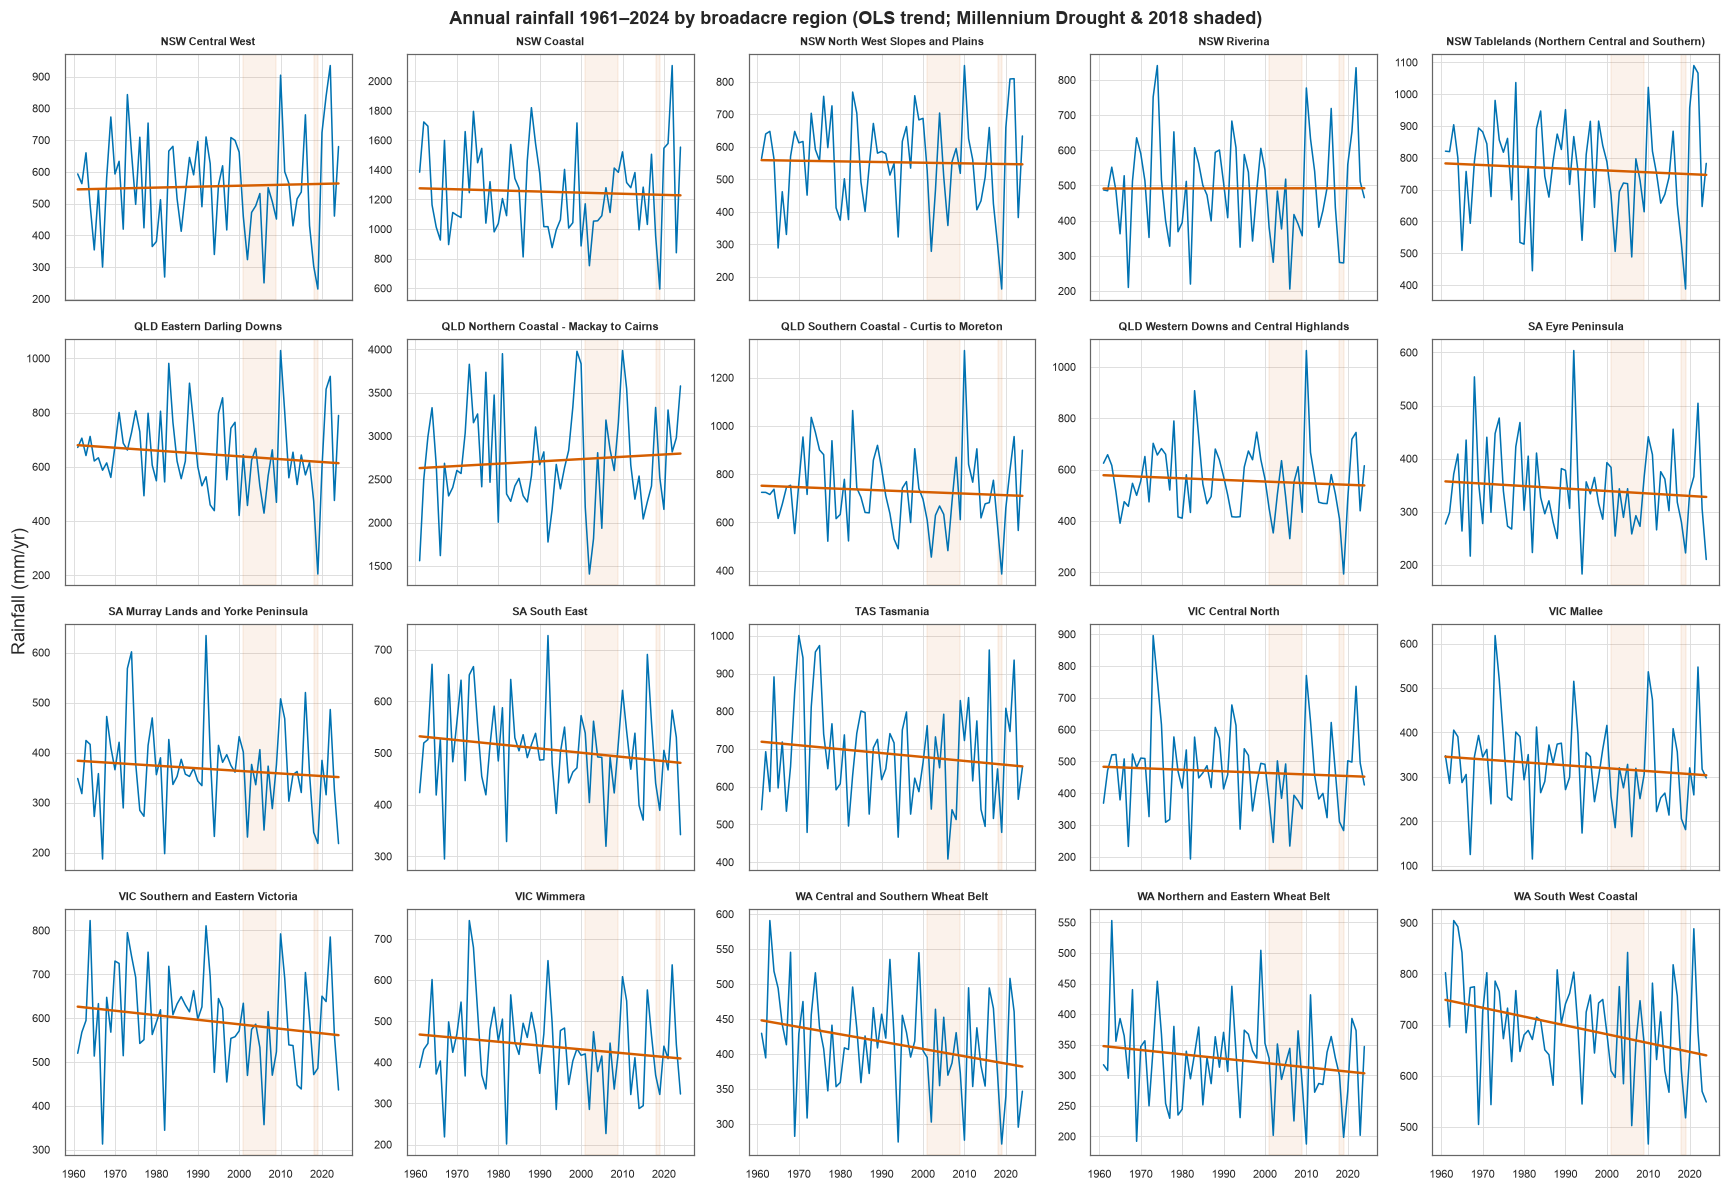

In [8]:
fig, axs = plt.subplots(4, 5, figsize=(16, 11), sharex=True)
for ax, (_, r) in zip(axs.ravel(), broad.iterrows()):
    s = ann[(ann.aagis_code == r.aagis_code) & (ann.variable == "daily_rain")].sort_values(
        "year"
    )
    ax.plot(s.year, s.value, lw=1, color=OKABE_ITO[0])
    b = np.polyfit(s.year, s.value, 1)
    ax.plot(s.year, np.polyval(b, s.year), lw=1.6, color=OKABE_ITO[3])
    for span in [(2001, 2009), (2018, 2019)]:
        ax.axvspan(*span, color="#D55E00", alpha=0.08)
    ax.set_title(r.region_name, fontsize=7.5)
    ax.tick_params(labelsize=7)
for ax in axs.ravel()[len(broad):]:
    ax.axis("off")
fig.suptitle(
    "Annual rainfall 1961–2024 by broadacre region "
    "(OLS trend; Millennium Drought & 2018 shaded)",
    fontweight="bold",
)
fig.supylabel("Rainfall (mm/yr)")
fig.tight_layout()
savefig(fig, "s02_rainfall_series_small_multiples")
plt.show()


**Interpretation.** Year-to-year rainfall variability is large in every region, but the OLS trend is downward across most of the southern cropping belt — clearest in the WA wheat-belt, WA South West Coastal, SA South East, and VIC — while NSW/QLD are flatter and noisier. The Millennium Drought (2001–2009) and 2018 stand out as sustained low-rain episodes in the southeast (carried into the s04 historical-event sanity check).

### 1.4 Warming — max-temperature anomaly vs 1961–1990

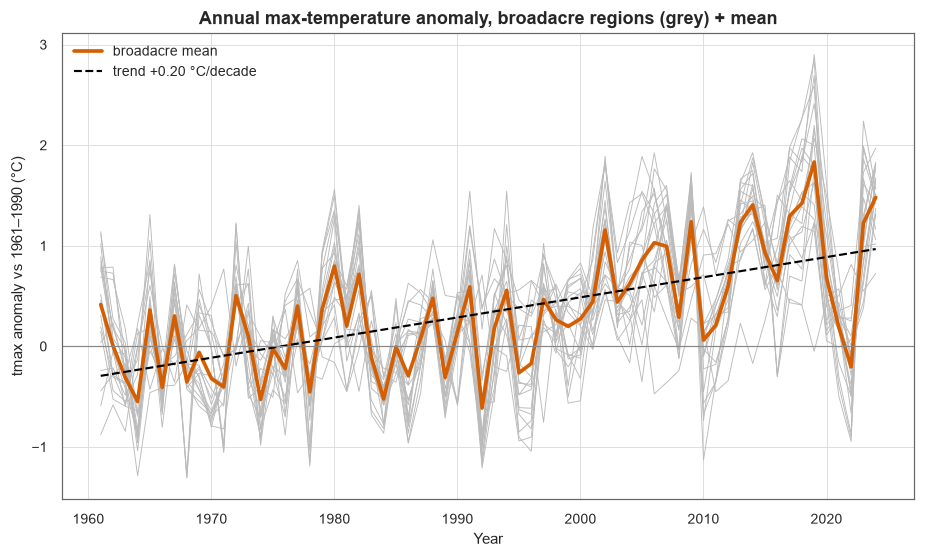

In [9]:
base = (
    bl[(bl.variable == "max_temp") & (bl.baseline == "1961-1990")]
    .set_index("aagis_code").value
)
mt = ann[ann.variable == "max_temp"]
fig, ax = plt.subplots(figsize=(10, 5.5))
series = []
for c in broad.aagis_code:
    s = mt[mt.aagis_code == c].sort_values("year")
    anom = s.value.values - base[c]
    ax.plot(s.year, anom, lw=0.6, color="#BBBBBB")
    series.append(pd.Series(anom, index=s.year.values))
mean_anom = pd.concat(series, axis=1).mean(axis=1)
ax.plot(mean_anom.index, mean_anom.values, lw=2.4, color=OKABE_ITO[3], label="broadacre mean")
b = np.polyfit(mean_anom.index, mean_anom.values, 1)
ax.plot(
    mean_anom.index, np.polyval(b, mean_anom.index), lw=1.4, ls="--",
    color=OKABE_ITO[7], label=f"trend {b[0] * 10:+.2f} °C/decade",
)
ax.axhline(0, color="#888888", lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("tmax anomaly vs 1961–1990 (°C)")
ax.set_title("Annual max-temperature anomaly, broadacre regions (grey) + mean")
ax.legend()
savefig(fig, "s02_tmax_anomaly")
plt.show()


**Interpretation.** Max temperature rises in **all 20** broadacre regions; the broadacre-mean anomaly trends at roughly **+0.2 °C/decade** over 1961–2024 (per-region OLS slopes span +0.05 to +0.26 °C/decade), i.e. ~1 °C of warming across the record. The warming is monotonic and spatially coherent — a clean climate-change signal that the yield-linkage models (Pillar 3) will test against production.

### 1.5 How much it varies — interannual rainfall variability

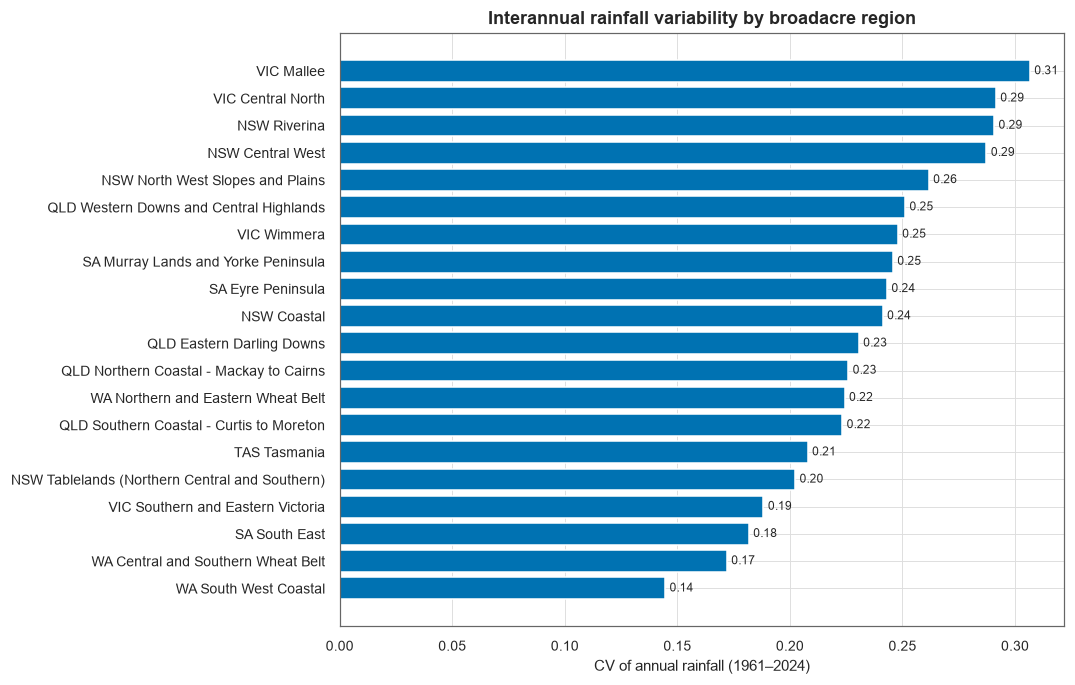

In [10]:
cv = (
    ann[(ann.variable == "daily_rain") & ann.aagis_code.isin(broad_codes)]
    .groupby(["aagis_code", "region_name"]).value.agg(lambda s: s.std() / s.mean())
    .sort_values()
)
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.barh([n for _, n in cv.index], cv.values, color=OKABE_ITO[0])
for i, v in enumerate(cv.values):
    ax.text(v + 0.002, i, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlabel("CV of annual rainfall (1961–2024)")
ax.set_title("Interannual rainfall variability by broadacre region")
savefig(fig, "s02_rainfall_cv")
plt.show()


**Interpretation.** The coefficient of variation of annual rainfall is highest in the dry interior/Mallee (VIC Mallee 0.31, VIC Central North and NSW Riverina ~0.29) and lowest in the Mediterranean south-west (WA South West Coastal 0.14, WA Wheat Belt 0.17, SA South East 0.18). Drier regions are also the *most variable* — a first, purely climatic, signature of where production risk exposure concentrates (to be matched against yield dispersion in s03).

### 1.6 Climate change signal — baseline shift (1991–2020 vs 1961–1990)

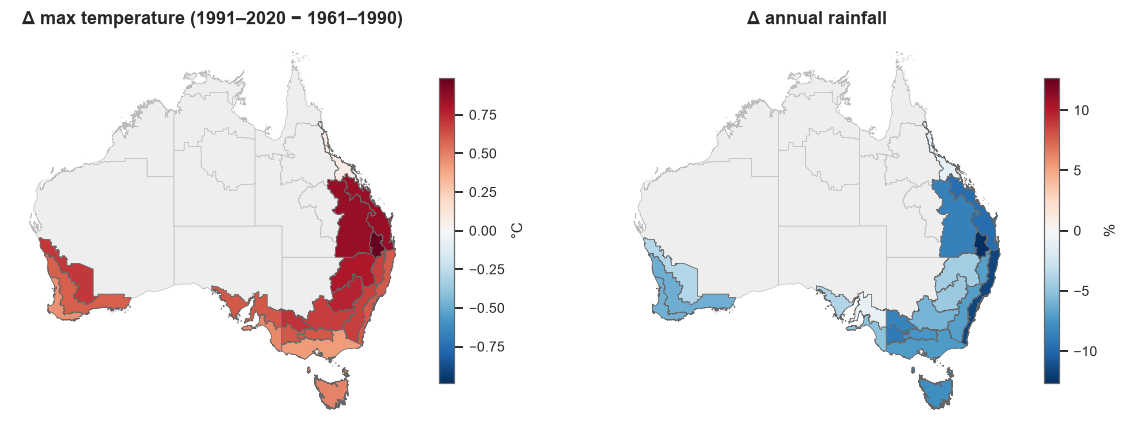

In [11]:
tw = blw[blw.variable == "max_temp"].assign(
    dtmax=lambda d: d["1991-2020"] - d["1961-1990"]
)
rw = blw[blw.variable == "daily_rain"].assign(
    drain=lambda d: 100 * (d["1991-2020"] - d["1961-1990"]) / d["1961-1990"]
)
fig, axs = plt.subplots(1, 2, figsize=(13, 6))
maps.region_choropleth(
    tw[["aagis_code", "dtmax"]], "dtmax", ax=axs[0], cmap=CMAP_ANOMALY, label="°C",
    title="Δ max temperature (1991–2020 − 1961–1990)", diverging=True,
)
maps.region_choropleth(
    rw[["aagis_code", "drain"]], "drain", ax=axs[1], cmap=CMAP_ANOMALY, label="%",
    title="Δ annual rainfall", diverging=True,
)
savefig(fig, "s02_baseline_shift")
plt.show()


**Interpretation.** Between the two WMO reference periods, max temperature rose in **every** broadacre region (median +0.61 °C, up to ~+1.0 °C in inland QLD) and annual rainfall fell in **every** broadacre region (median −6.6%, up to −13% in the east). Warming-and-drying is thus a whole-of-belt shift, not a regional artefact — the central climate premise the risk analysis rests on. (evap_pan's 1961–1990 baseline uses 1970–1990 only; see s02 methodology.)

### 1.7 Climate EDA synthesis (where / when / how much)

- **Where:** a hot-dry interior/western belt vs a cooler-wetter east/south; rainfall ~300 mm/yr (WA/Mallee) to >900 mm/yr (eastern/coastal).
- **When:** winter-dominant rainfall in the south/west (aligned to winter crops), summer-dominant in QLD.
- **How much:** large interannual variability everywhere, highest in the dry interior (CV up to 0.31); a coherent warming trend (~+0.2 °C/decade, 20/20 regions) and a whole-belt drying shift (median −6.6%, 20/20 regions).

These climatic patterns frame the yield analysis in s03 and the historical-event sanity check in s04.

## 2. Yield trends & dispersion (ABARES)

*To be populated in s03.* Region-level yield trends and dispersion for wheat / barley / canola, reliable-window filtering, and lower-tail (risk-relevant) distributional properties.

**Open decision (gate ②):** RSE weighting — diagnostic-only vs inverse-RSE regression weights (may be deferred to Phase 06).


## 3. Climate–yield joint view & historical-event sanity

*To be populated in s04.* Region-year alignment of climate and yield, preliminary correlation views, and a sanity overlay of known events — Millennium Drought (2001–2009), the 2018 drought, and the 2013 / 2017 heat — against the SILO / yield series (Task H; formal historical-event validation remains Phase 09).


## 4. Optional-crop evidence & decision (sorghum / cotton)

*To be populated in s05.* Evidence-led decision on the optional crops, on the basis of ABARES FDP region-year data availability, homogeneity with the rainfed broadacre framing (cotton is irrigated; sorghum is a summer crop with a different climate window), methodological cost, and marginal portfolio signal.


## 5. EDA synthesis — where, when, how much

*To be consolidated at s06.* The Phase 03 exit-criterion narrative across climate and yield.


## Limitations & caveats (running list)

- **ACORN-SAT station truth** is weak for QLD Eastern Darling Downs (no station) and sparse for NSW Central West, VIC Wimmera, VIC Central North, WA South West Coastal.
- **Reliable yield windows:** wheat/barley 1990+, canola 1994+ (RSE gate).
- **evap_pan** is observed only from 1970, so its 1961–1990 baseline uses 1970–1990.
- **Trends here are descriptive (OLS)**, not inferential; formal trend/return-period testing is Pillar 2 (Phase 05).
- **Observed-vs-derived discipline:** ABARES observed yields are the target; AGFD (Phase 09) is validation only.
